In [2]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
torch.__version__ ,torchvision.__version__

('2.11.0+cu128', '0.26.0+cu128')

In [3]:
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 199kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.75MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.2MB/s]


In [4]:
image,label = train_data[0]
image,label,image.shape

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [5]:
classess = train_data.classes

Text(0.5, 1.0, 'Ankle boot')

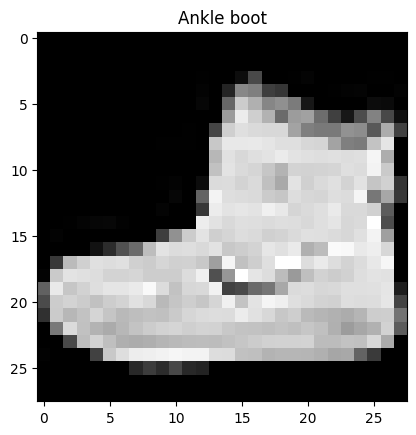

In [6]:
plt.imshow(image.squeeze(),cmap="gray")
plt.title(classess[label])

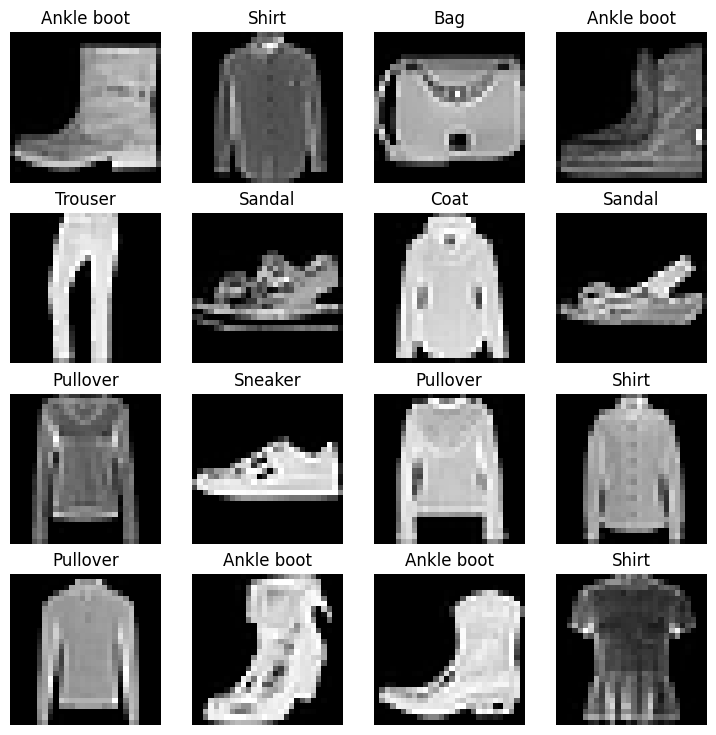

In [7]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
row,colm = 4,4
for i in range(1,row*colm +1):
    random_idx = torch.randint(0,len(train_data),size=[1]).item()
    img,label=train_data[random_idx]
    fig.add_subplot(row,colm,i)
    plt.imshow(img.squeeze(),cmap="gray")
    plt.title(classess[label])
    plt.axis(False);



In [8]:
from torch.utils.data import DataLoader

batch_size = 32


train_dataloader = DataLoader(train_data,batch_size,True)
test_dataloader = DataLoader(test_data,batch_size,False)

print(f"Dataloader : {train_dataloader,test_dataloader}")
print(f"Length of train Dataloader : {len(train_dataloader)},batch of {batch_size}")
print(f"Length of test Dataloader : {len(test_dataloader)},batch of {batch_size}")


Dataloader : (<torch.utils.data.dataloader.DataLoader object at 0x7d0a3268a270>, <torch.utils.data.dataloader.DataLoader object at 0x7d0a319e0830>)
Length of train Dataloader : 1875,batch of 32
Length of test Dataloader : 313,batch of 32


In [9]:
train_feature_batch ,train_label_batch=next(iter(train_dataloader))
train_feature_batch.shape ,train_label_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

(torch.Size([1, 28, 28]), tensor(6), torch.Size([]))

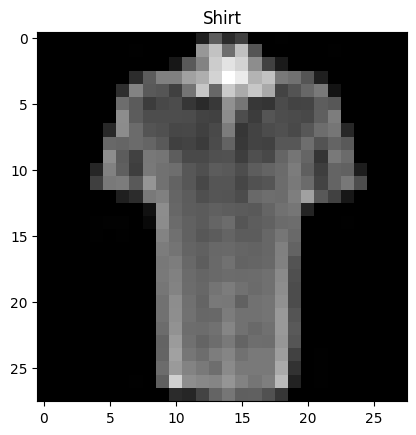

In [10]:
torch.manual_seed(42)
random_idx = torch.randint(0,len(train_feature_batch),size=[1]).item()
img,label = train_feature_batch[random_idx],train_label_batch[random_idx]
plt.imshow(img.squeeze(),cmap="gray")
plt.title(classess[label])
img.shape,label,label.shape

In [11]:
flatten_model = nn.Flatten()
x=train_feature_batch[0]
output = flatten_model(x)
print(f"shape before slattening : {x.shape}")
print(f"shape after slattening : {output.shape}")

x,output


shape before slattening : torch.Size([1, 28, 28])
shape after slattening : torch.Size([1, 784])


(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0039, 0.0039, 0.0000, 0.0000, 0.0078, 0.0078, 0.0000,
           0.0000, 0.0039, 0.0078, 0.0000, 

In [12]:

class FashionMNISTModelV0(nn.Module):
    def __init__(self,input_shape: int , hidden_shape:int,output_shape:int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_shape,hidden_shape),
            nn.Linear(hidden_shape,output_shape)
        )

    def forward(self,x):
        return self.layer_stack(x)

torch.manual_seed(42)
model_0 = FashionMNISTModelV0(784,10,len(classess))
model_0.to("cpu")

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [13]:
# from helper_functions import accuracy_fn
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_0.parameters(),lr=0.1)

In [14]:
from timeit import default_timer as Timer
def print_train_time(start:float,end:float,device:torch.device=None):
    """print time between start and end time.

    Args:
        start,end:u know what to do with it(nothing).

    Returns:
        total time:it do automatically:-) """

    total_time = end - start
    print(f"Train time on {device} : {total_time:.3f}second")
    return total_time



In [15]:
from tqdm.auto import tqdm
torch.manual_seed(42)
train_time_start_on_cpu = Timer()
epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch : {epoch}\n------")
    train_loss=0
    model_0.train()
    for batch, (X,y) in enumerate(train_dataloader):

        y_pred = model_0(X)

        loss=loss_fn(y_pred,y)
        train_loss += loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        if batch % 400 == 0:
            print(f"Looked at {batch *len(X)}/{len(train_dataloader.dataset)} samples")

    train_loss /= len(train_dataloader)

    test_loss, test_acc = 0,0
    model_0.eval()
    with torch.inference_mode():
        for X,y in test_dataloader:
            test_pred=model_0(X)
            test_loss += loss_fn(test_pred,y)
            test_acc +=accuracy_fn(y,test_pred.argmax(dim=1))

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

    print(f"\nTrain loss: {train_loss:.5f} | test loss: {test_loss:.5f},Test acc: {test_acc:.2f}%\n")

train_time_end_on_cpu = Timer()
total_train_time_model_0 = print_train_time(train_time_start_on_cpu,train_time_end_on_cpu,str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch : 0
------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.59039 | test loss: 0.50954,Test acc: 82.04%

Epoch : 1
------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.47633 | test loss: 0.47989,Test acc: 83.20%

Epoch : 2
------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.45503 | test loss: 0.47664,Test acc: 83.43%

Train time on cpu : 28.351second


In [16]:
torch.manual_seed(42)
def eval_model(model:torch.nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               accuracy_fn):
    """Returns a dictionary containing the results of model predicting on data_loader.

        Args:
            model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
            data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
            loss_fn (torch.nn.Module): The loss function of model.
            accuracy_fn: An accuracy function to compare the models predictions to the truth labels.

        Returns:
            (dict): Results of model making predictions on data_loader.
        """
    loss,acc =0, 0
    model.eval()
    with torch.inference_mode():
        for X,y in dataloader:
            y_pred = model(X)
            loss+=loss_fn(y_pred,y)
            acc += accuracy_fn(y,y_pred.argmax(dim=1))

        loss /= len(dataloader)
        acc /= len(dataloader)

    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item()
            ,"model_acc":acc}

model_0_result=eval_model(model_0,test_dataloader,loss_fn,accuracy_fn)
model_0_result

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

In [17]:
!nvidia-smi

Sun Jul 26 12:12:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [18]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [19]:
class FashionMNISTModelV1(nn.Module):
  def __init__(self,input_shape:int,output_shape:int,hidden_shape:int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(input_shape,hidden_shape),
        nn.ReLU(),
        nn.Linear(hidden_shape,output_shape),
        nn.ReLU()
        )
  def forward(self,x:torch.Tensor):
    return self.layer_stack(x)

torch.manual_seed(42)
model_1 = FashionMNISTModelV1(784,10,len(classess)).to(device).to(device)
next(model_1.parameters()).device




device(type='cuda', index=0)

In [20]:
loss_fn=nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_1.parameters(),lr=0.1)

In [21]:
def train_step(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               accuracy_fn,
               device:torch.device = device):
  train_loss,train_acc = 0,0
  model.to(device)
  model.train()
  for batch,(X,y) in enumerate(data_loader):
    X,y = X.to(device),y.to(device)
    y_pred=model(X)
    loss = loss_fn(y_pred,y)
    train_loss += loss
    train_acc += accuracy_fn(y,y_pred.argmax(dim=1))

    optimizer.zero_grad()

    loss.backward()
    optimizer.step()
  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"Train loss: {train_loss:.5f} | Train acc:{train_acc:.2f}%")


def test_step(model:torch.nn.Module,
              data_loader:torch.utils.data.DataLoader,
              loss_fn:torch.nn.Module,
              accuracy_fn,
              device:torch.device=device):
  test_loss,test_acc = 0,0
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for X,y in data_loader:
      X,y = X.to(device),y.to(device)
      test_pred = model(X)
      test_loss += loss_fn(test_pred,y)
      test_acc += accuracy_fn(y,test_pred.argmax(dim=1))

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"Test loss: {test_loss:.5f} | Test acc:{test_acc:.2f}%")

In [22]:
torch.manual_seed(42)

from timeit import default_timer as timer
train_time_start_on_gpu = Timer()

epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"epoch:{epoch}\n-------")
  train_step(model_1,
             train_dataloader,
             loss_fn,optimizer,
             accuracy_fn)

  test_step(model_1,
            test_dataloader,
            loss_fn,
            accuracy_fn)

  print("\n")

train_time_end_on_gpu = Timer()
total_train_time_model_1 = print_train_time(train_time_start_on_gpu,train_time_end_on_gpu,device)

  0%|          | 0/3 [00:00<?, ?it/s]

epoch:0
-------
Train loss: 1.09199 | Train acc:61.34%
Test loss: 0.95636 | Test acc:65.00%


epoch:1
-------
Train loss: 0.78101 | Train acc:71.93%
Test loss: 0.72227 | Test acc:73.91%


epoch:2
-------
Train loss: 0.67027 | Train acc:75.94%
Test loss: 0.68500 | Test acc:75.02%


Train time on cuda : 33.299second


In [23]:
torch.manual_seed(42)
def eval_model(model:torch.nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               accuracy_fn,
               device:torch.device):
    """Returns a dictionary containing the results of model predicting on data_loader.

        Args:
            model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
            data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
            loss_fn (torch.nn.Module): The loss function of model.
            accuracy_fn: An accuracy function to compare the models predictions to the truth labels.

        Returns:
            (dict): Results of model making predictions on data_loader.
        """
    loss,acc =0, 0
    model.eval()
    with torch.inference_mode():
        for X,y in dataloader:
            X,y = X.to(device),y.to(device)
            y_pred = model(X)
            loss+=loss_fn(y_pred,y)
            acc += accuracy_fn(y,y_pred.argmax(dim=1))

        loss /= len(dataloader)
        acc /= len(dataloader)

    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item()
            ,"model_acc":acc}


In [24]:
torch.manual_seed(42)
model_1_result = eval_model(model_1,test_dataloader,loss_fn,accuracy_fn,"cuda")
model_1_result

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6850008964538574,
 'model_acc': 75.01996805111821}

In [25]:
model_0_result=eval_model(model_0,test_dataloader,loss_fn,accuracy_fn,"cpu")
model_0_result

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

In [26]:
class FashionMNISTModelV2(nn.Module):
  def __init__(self,input_shape:int,hidden_layer:int,output_layer:int):
    super().__init__()
    self.block_1 = nn.Sequential(
        nn.Conv2d(input_shape,
                  hidden_layer,
                  3,
                  1,
                  1),
        nn.ReLU(),
        nn.Conv2d(hidden_layer,
                  hidden_layer,
                  3,
                  1,
                  1),
        nn.ReLU(),
        nn.MaxPool2d(2,
                     2)
    )
    self.block_2 = nn.Sequential(
        nn.Conv2d(hidden_layer,
                  hidden_layer,3,1,1),
        nn.ReLU(),
        nn.Conv2d(hidden_layer,hidden_layer,3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(hidden_layer*7*7,output_layer)
    )

  def forward(self,x:torch.Tensor):
    x = self.block_1(x)
    x = self.block_2(x)
    x = self.classifier(x) # Add this line to pass through the classifier
    return x

torch.manual_seed(42)
model_2 = FashionMNISTModelV2(1,10,len(classess)).to(device)
model_2

FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [27]:
torch.manual_seed(42)
image = torch.randn((32,3,64,64))
test_image = image[0]
image.shape,test_image.shape,test_image

(torch.Size([32, 3, 64, 64]),
 torch.Size([3, 64, 64]),
 tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
          [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
          [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
          ...,
          [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
          [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
          [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],
 
         [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
          [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
          [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
          ...,
          [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
          [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
          [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],
 
         [[-0.7978,  1.0261,  1.1465,  ..., 

In [28]:
torch.manual_seed(42)
conv_layer = nn.Conv2d(3,10,5,2,0)
conv_layer(image),image.shape,conv_layer(image).shape

(tensor([[[[-5.9479e-01, -1.5861e+00,  8.0461e-01,  ..., -6.7599e-01,
            -4.1413e-01,  4.6227e-01],
           [-2.8077e-02, -1.2165e+00,  5.2685e-01,  ..., -8.2507e-01,
            -2.7752e-01, -2.4841e-01],
           [-1.6578e-01,  4.6476e-01, -3.0047e-01,  ..., -9.0986e-01,
            -4.3569e-01,  2.9786e-01],
           ...,
           [ 6.6302e-01,  1.1410e-01,  5.5437e-01,  ..., -1.0168e+00,
            -3.6451e-01,  4.7651e-01],
           [ 3.4960e-01,  8.9339e-01, -5.5668e-01,  ..., -2.9243e-01,
             2.3048e-01,  1.0192e+00],
           [-8.4161e-01,  1.7929e-01, -1.0850e-01,  ...,  1.4768e-01,
            -1.6401e+00, -6.6306e-01]],
 
          [[ 1.3999e-01, -1.0109e+00,  1.7282e-01,  ..., -6.4950e-01,
            -2.6063e-01, -7.5165e-01],
           [ 1.5869e-01,  1.5218e+00,  3.4198e-01,  ...,  5.7672e-01,
             7.0924e-01,  1.9650e-01],
           [ 4.2027e-02,  2.2193e-01, -5.8868e-01,  ..., -1.6640e+00,
            -6.5378e-01, -6.5954e-01],


In [29]:
test_image.unsqueeze(0).shape

torch.Size([1, 3, 64, 64])

In [30]:
conv_layer(test_image.unsqueeze(0)).shape

torch.Size([1, 10, 30, 30])

In [31]:
conv_layer(test_image.unsqueeze(0)).shape

torch.Size([1, 10, 30, 30])

In [32]:
print(conv_layer.state_dict())

OrderedDict({'weight': tensor([[[[ 0.0883,  0.0958, -0.0271,  0.1061, -0.0253],
          [ 0.0233, -0.0562,  0.0678,  0.1018, -0.0847],
          [ 0.1004,  0.0216,  0.0853,  0.0156,  0.0557],
          [-0.0163,  0.0890,  0.0171, -0.0539,  0.0294],
          [-0.0532, -0.0135, -0.0469,  0.0766, -0.0911]],

         [[-0.0532, -0.0326, -0.0694,  0.0109, -0.1140],
          [ 0.1043, -0.0981,  0.0891,  0.0192, -0.0375],
          [ 0.0714,  0.0180,  0.0933,  0.0126, -0.0364],
          [ 0.0310, -0.0313,  0.0486,  0.1031,  0.0667],
          [-0.0505,  0.0667,  0.0207,  0.0586, -0.0704]],

         [[-0.1143, -0.0446, -0.0886,  0.0947,  0.0333],
          [ 0.0478,  0.0365, -0.0020,  0.0904, -0.0820],
          [ 0.0073, -0.0788,  0.0356, -0.0398,  0.0354],
          [-0.0241,  0.0958, -0.0684, -0.0689, -0.0689],
          [ 0.1039,  0.0385,  0.1111, -0.0953, -0.1145]]],


        [[[-0.0903, -0.0777,  0.0468,  0.0413,  0.0959],
          [-0.0596, -0.0787,  0.0613, -0.0467,  0.0701],


In [33]:
conv_layer.weight.shape,conv_layer.bias.shape

(torch.Size([10, 3, 5, 5]), torch.Size([10]))

In [34]:
print(f"Test image original shape: {test_image.shape}")
print(f"Test image with unsqueezed dimension: {test_image.unsqueeze(dim=0).shape}")

max_pool_layer = nn.MaxPool2d(kernel_size=2)

conv_layer(test_image.unsqueeze(dim=0)).shape,max_pool_layer(conv_layer(test_image.unsqueeze(dim=0))).shape

Test image original shape: torch.Size([3, 64, 64])
Test image with unsqueezed dimension: torch.Size([1, 3, 64, 64])


(torch.Size([1, 10, 30, 30]), torch.Size([1, 10, 15, 15]))

In [35]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_2.parameters(),lr=0.1)

In [36]:
torch.manual_seed(42)
start = Timer()
epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"epoch:{epoch}\n-------")
  train_step(model_2,train_dataloader,loss_fn,optimizer,accuracy_fn,device="cuda")

  test_step(model_2,test_dataloader,loss_fn,accuracy_fn,"cuda")

end = Timer()
total_train_time_model_2 = print_train_time(start,end,device)


  0%|          | 0/3 [00:00<?, ?it/s]

epoch:0
-------
Train loss: 0.60020 | Train acc:78.20%
Test loss: 0.39616 | Test acc:85.95%
epoch:1
-------
Train loss: 0.36124 | Train acc:87.02%
Test loss: 0.34544 | Test acc:87.15%
epoch:2
-------
Train loss: 0.32279 | Train acc:88.27%
Test loss: 0.32204 | Test acc:88.20%
Train time on cuda : 41.380second


In [37]:
model_2_result = eval_model(model_2,test_dataloader,loss_fn,accuracy_fn,"cuda")
model_2_result

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32203543186187744,
 'model_acc': 88.19888178913737}

In [38]:
import pandas as pd
model_compare = pd.DataFrame([model_0_result,model_1_result,model_2_result])
model_compare

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.476639,83.426518
1,FashionMNISTModelV1,0.685001,75.019968
2,FashionMNISTModelV2,0.322035,88.198882


In [39]:
model_compare["training_time"] = [total_train_time_model_0,total_train_time_model_1,total_train_time_model_2]
model_compare

,model_name,model_loss,model_acc,training_time
0,FashionMNISTModelV0,0.476639,83.426518,28.351289
1,FashionMNISTModelV1,0.685001,75.019968,33.298636
2,FashionMNISTModelV2,0.322035,88.198882,41.380302


,model_name,model_loss,model_acc,training_time
0,FashionMNISTModelV0,0.476639,83.426518,28.351289
1,FashionMNISTModelV1,0.685001,75.019968,33.298636
2,FashionMNISTModelV2,0.322035,88.198882,41.380302


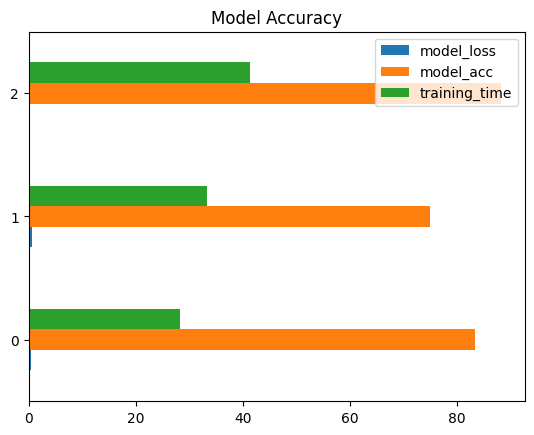

In [40]:
model_compare.plot(kind="barh",title="Model Accuracy")
model_compare

In [41]:
def make_prediction(model:torch.nn.Module,
                    data:list,
                    device:torch.device = device):

  pred_probs = []
  model.eval()
  with torch.inference_mode():
    for sample in data:
      sample = torch.unsqueeze(sample,dim=0).to(device)
      pred_logit = model(sample)
      pred_prob = torch.softmax(pred_logit.squeeze(),dim=0)
      pred_probs.append(pred_prob.cpu())

  return torch.stack(pred_probs)

In [42]:
import random
random.seed(42)
test_samples = []
test_labels = []
for sample,label in random.sample(list(test_data),k=9):
  test_samples.append(sample)
  test_labels.append(label)

test_samples[0].shape,test_labels[0],classess[test_labels[0]]

(torch.Size([1, 28, 28]), 5, 'Sandal')

In [86]:
import random
random.seed(42)

test_samples=[]
test_samples=[]
test_samples.clear()
test_labels.clear()
for a,b in random.sample(list(test_data),k=9):
  test_samples.append(a)
  test_labels.append(b)
# a.shape,b.shape
# a[:5],b[:5]
print(f"Test sample image shpe: {test_samples[0].shape} | Test label: {test_labels[0]}({classess[test_labels[0]]})")

Test sample image shpe: torch.Size([1, 28, 28]) | Test label: 5(Sandal)


In [87]:
pred_probs = make_prediction(model_2,test_samples)
pred_probs[:2]

tensor([[2.0390e-08, 2.8414e-08, 8.2766e-09, 1.9872e-08, 2.2775e-09, 9.9996e-01,
         2.3735e-07, 1.7801e-06, 3.6341e-06, 3.1174e-05],
        [1.5375e-02, 6.9203e-01, 1.0043e-03, 1.0898e-01, 1.1138e-01, 4.8561e-05,
         7.0030e-02, 2.8613e-04, 2.9648e-04, 5.6962e-04]])

In [88]:
pred_class = pred_probs.argmax(dim=1)
pred_class[:]

tensor([5, 1, 7, 4, 3, 0, 4, 7, 1])

In [89]:
test_labels,pred_class

([5, 1, 7, 4, 3, 0, 4, 7, 1], tensor([5, 1, 7, 4, 3, 0, 4, 7, 1]))

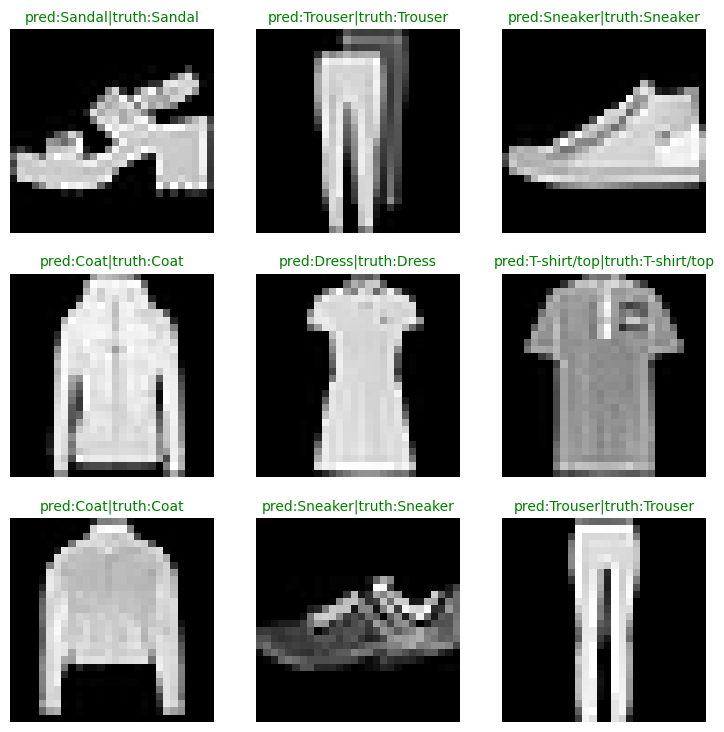

In [95]:
plt.figure(figsize=(9,9))
nrow = 3
ncol = 3
for i , sample in enumerate(test_samples):
  plt.subplot(nrow,ncol,i+1)
  plt.imshow(sample.squeeze(),cmap="gray")
  pred_label = classess[pred_class[i]]
  truth_label = classess[test_labels[i]]
  title_text = f"pred:{pred_label}|truth:{truth_label}"
  if pred_label == truth_label:
    plt.title(title_text,fontsize=10,c="green")
  else:
    plt.title(title_text,fontsize=10,c="red")
  plt.axis(False)
  # plt.title(f"Pred: {classess[pred_class[i]]} | Truth: {classess[test_labels[i]]}")

In [106]:
from tqdm.auto import tqdm
y_preds = []
model_2.eval()
with torch.inference_mode():
  for x,y in tqdm(test_dataloader,desc="making prediction.."):
    x,y=x.to(device),y.to(device)
    y_logits=model_2(x)
    y_pred=torch.softmax(y_logits,dim=1).argmax(dim=1)
    y_preds.append(y_pred.cpu())

y_pred_tensor = torch.cat(y_preds)

making prediction..:   0%|          | 0/313 [00:00<?, ?it/s]

<Axes: >

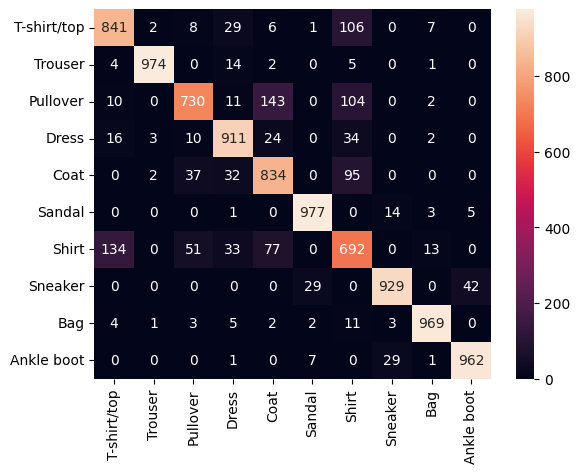

In [110]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_data.targets,y_pred_tensor)
import seaborn as sns
sns.heatmap(cm,annot=True,fmt="d",xticklabels=classess,yticklabels=classess)

In [101]:
test_data.targets

tensor([9, 2, 1,  ..., 8, 1, 5])

In [115]:
from pathlib import Path
model = Path("model")
model.mkdir(parents=True,exist_ok=True)
torch.save(model_2.state_dict(),model/"model_2.pth")

In [116]:
model_path=model/"model_2.pth"
loaded_model_2 = FashionMNISTModelV2(1,10,10)
loaded_model_2.load_state_dict(torch.load(f=model_path))
loaded_model_2=loaded_model_2.to(device)

In [117]:
loaded_model_2_result=eval_model(loaded_model_2,test_dataloader,loss_fn,accuracy_fn,"cuda")
loaded_model_2_result

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32203543186187744,
 'model_acc': 88.19888178913737}

In [118]:
model_2_result

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32203543186187744,
 'model_acc': 88.19888178913737}

In [124]:
torch.isclose(torch.tensor(model_2_result["model_loss"]),torch.tensor(loaded_model_2_result["model_loss"]))

tensor(True)